# Matplotlib

* Veri seti oluşturma
* Veri seti inceleme
* Veri setinin temel istatistiksel özellikleri
* Görselleştirme
    * Matplotlib
    * Seaborn

## Veri seti oluşturma
* Örnek veri seti oluştur (kategorik, sayısal değerler olsun)
* Müşteri bilgileri:
  * müsteriID: pk (int)
  * yas: int
  * gelir: float
  * cinsiyet: kategorik
  * sehir: kategorik
  * alısveris_sayisi: int
  * memnuniyet: float(1-5)

In [113]:
import pandas as pd
import numpy as np

# örnek veri seti oluşturma
np.random.seed(42)
veri = pd.DataFrame({
    "musteri_id" : range(1,21),
    "cinsiyet" : np.random.choice(["erkek", "kadın"], 20),
    "yas" : np.random.randint(18,60,20),
    "gelir" : np.random.uniform(3000, 15000, 20).round(2),
    "sehir" : np.random.choice(["Ankara", "İstanbul", "İzmir", "Bursa", "Elazig"], 20),
    "alısveris_sayisi" : np.random.randint(1,20,20),
    "memnuniyet" : np.random.uniform(1,5,20).round(1)

})



In [114]:
veri

,musteri_id,cinsiyet,yas,gelir,sehir,alısveris_sayisi,memnuniyet
0,1,erkek,39,8405.99,Bursa,7,2.3
1,2,kadın,19,3159.18,İstanbul,9,1.3
2,3,erkek,41,14306.42,İstanbul,1,2.2
3,4,erkek,47,9759.46,Bursa,12,2.3
4,5,erkek,55,7625.00,Bursa,8,3.9
5,6,kadın,19,3191.60,Ankara,11,3.6
6,7,erkek,38,5770.73,Elazig,19,4.5
7,8,erkek,50,5892.31,Elazig,17,2.9
8,9,erkek,29,11199.16,İstanbul,8,1.5
9,10,kadın,39,10319.96,Elazig,3,3.9


## Veri seti inceleme
Bu bölümde bir veri setini analiz etmeden önce tanımayı, yapısını anlamayı ve temel özet bilgilerini çıkarmayı öğrenicez.
Veriyi iyi tanımak doğru analiz ve modelleme için çok önemlidir.
Bu nedenle veri setinin
* özelliklerini
* eksiklerini
* dağılımını
anlamak çok önemlidir.

Bu bölümde:
* veri setinin genel görünümü
* veri tipleri, eksik değerler, bellek kullanımı
* sayısal, kategorik değerleri ayırma
* Temel ist özellikleri alma
* Eksik ve tekrar eden verileri kontrol etme
* Korelasyon ve temel ilişkileri gözlemleme
* İlk görselleştirmeler ile genel dağılımı görme

### Veri setinin genel görünümü

In [115]:
veri.head()

,musteri_id,cinsiyet,yas,gelir,sehir,alısveris_sayisi,memnuniyet
0,1,erkek,39,8405.99,Bursa,7,2.3
1,2,kadın,19,3159.18,İstanbul,9,1.3
2,3,erkek,41,14306.42,İstanbul,1,2.2
3,4,erkek,47,9759.46,Bursa,12,2.3
4,5,erkek,55,7625.00,Bursa,8,3.9


In [116]:
veri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   musteri_id        20 non-null     int64  
 1   cinsiyet          20 non-null     object 
 2   yas               20 non-null     int64  
 3   gelir             20 non-null     float64
 4   sehir             20 non-null     object 
 5   alısveris_sayisi  20 non-null     int64  
 6   memnuniyet        20 non-null     float64
dtypes: float64(2), int64(3), object(2)
memory usage: 1.2+ KB


In [117]:
# temel istatistiksel bilgiler
veri.describe()

,musteri_id,yas,gelir,alısveris_sayisi,memnuniyet
count,20.00000,20.000000,20.000000,20.000000,20.000000
mean,10.50000,38.350000,8127.259000,8.300000,2.780000
std,5.91608,11.930831,3475.508974,4.635106,1.086084
min,1.00000,19.000000,3159.180000,1.000000,1.100000
25%,5.75000,31.250000,5418.182500,6.500000,2.025000
50%,10.50000,39.000000,7897.300000,8.000000,2.950000
75%,15.25000,45.500000,10539.760000,10.250000,3.675000
max,20.00000,59.000000,14306.420000,19.000000,4.500000


In [118]:
# veri setinin genel boyutu
veri.shape

(20, 7)

### Veri tipleri ve değişken türleri

In [119]:
veri.dtypes

,0
musteri_id,int64
cinsiyet,object
yas,int64
gelir,float64
sehir,object
alısveris_sayisi,int64
memnuniyet,float64


In [120]:
veri.select_dtypes(include = ["int64", "float64"]).columns.to_list()

['musteri_id', 'yas', 'gelir', 'alısveris_sayisi', 'memnuniyet']

In [121]:
# kategorik verileri bul
veri.select_dtypes(include = ["object"]).columns.to_list()

['cinsiyet', 'sehir']

### Eksik değer ve tekrarlanan satır kontrolü

In [122]:
# Eksik değer analizi
veri.isnull().sum()

,0
musteri_id,0
cinsiyet,0
yas,0
gelir,0
sehir,0
alısveris_sayisi,0
memnuniyet,0


In [123]:
# tekrarlanan satır kontrolü
veri.duplicated().sum()

np.int64(0)

### Kategorik ve sayısal değer dağılımı

In [124]:
for sutun in ["cinsiyet", "sehir"]:
  print(veri[sutun].unique())

['erkek' 'kadın']
['Bursa' 'İstanbul' 'Ankara' 'Elazig']


In [125]:
# kategorik değişkenlerin frekans dağılımı
for sutun in ["cinsiyet","sehir"]:
  print(veri[sutun].value_counts())

cinsiyet
erkek    13
kadın     7
Name: count, dtype: int64
sehir
Bursa       6
Elazig      6
İstanbul    4
Ankara      4
Name: count, dtype: int64


In [126]:
# sayısal değerlerin aralıkları
for sutun in ['musteri_id', 'yas', 'gelir', 'alısveris_sayisi', 'memnuniyet']:
  print(sutun, ":",veri[sutun].min(),"-", veri[sutun].max())

musteri_id : 1 - 20
yas : 19 - 59
gelir : 3159.18 - 14306.42
alısveris_sayisi : 1 - 19
memnuniyet : 1.1 - 4.5


### Korelasyon analizi

In [127]:
veri.corr(numeric_only=True)

,musteri_id,yas,gelir,alısveris_sayisi,memnuniyet
musteri_id,1.000000,-0.027962,0.056956,-0.034548,-0.103209
yas,-0.027962,1.000000,0.321997,-0.037213,0.431925
gelir,0.056956,0.321997,1.000000,-0.330335,0.150770
alısveris_sayisi,-0.034548,-0.037213,-0.330335,1.000000,0.085940
memnuniyet,-0.103209,0.431925,0.150770,0.085940,1.000000


### Basit görsel inceleme

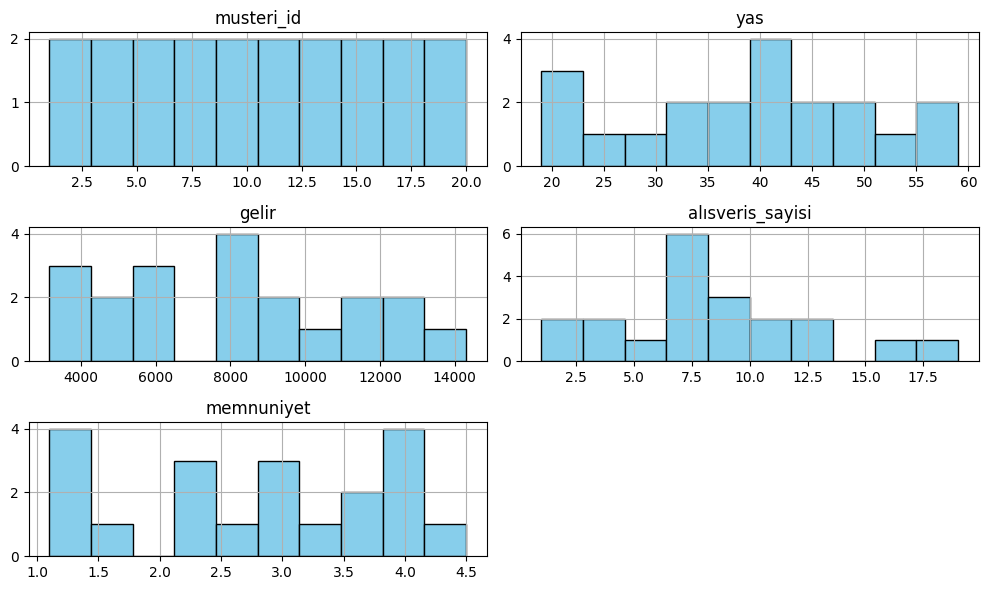

In [128]:
import matplotlib.pyplot as plt
# bins: bar sayısı
veri.hist(figsize=(10,6), bins= 10, color= "skyblue" , edgecolor= "black")
plt.tight_layout()
plt.show()

> Veri setinin yapısı, türleri boyutu, eksik veya tekrarlayan kayıt, sayısal değişkenlerin temel istatistiksel yorumlaması, kategorik değişkenlerin dağılımları, basit görsel

## Temel Istatistiksel Özellikler
Veri setindeki sayısal değişkenlerin derinlemesine analizi ve verinin genel istatistiksel yapısını anlamak.
> veri ne kadar ort değer etrafında yoğunlaşmış?

> Değerler arasında nasıl bir ilişki var?

> Dağılım dengeli mi?

* Ortalama, median, mode hesabı
* vayans, std inceleme
* min, max, çeyrek değerler (quantile)
* Korelasyon analizi

### ortalama medyan mod

In [129]:
# mean
veri[["yas","gelir","alısveris_sayisi", "memnuniyet"]].mean()

,0
yas,38.350
gelir,8127.259
alısveris_sayisi,8.300
memnuniyet,2.780


In [130]:
# mean
veri[["yas","gelir","alısveris_sayisi", "memnuniyet"]].median()

,0
yas,39.00
gelir,7897.30
alısveris_sayisi,8.00
memnuniyet,2.95


In [131]:
# mean
veri[["yas","alısveris_sayisi"]].mode()

,yas,alısveris_sayisi
0,19,7
1,38,8
2,39,9


### Dağılım ölçüleri - varyans, std, min, max

In [132]:
veri[["yas","gelir","alısveris_sayisi", "memnuniyet"]].var()

,0
yas,1.423447e+02
gelir,1.207916e+07
alısveris_sayisi,2.148421e+01
memnuniyet,1.179579e+00


In [133]:
veri[["yas","gelir","alısveris_sayisi", "memnuniyet"]].std()

,0
yas,11.930831
gelir,3475.508974
alısveris_sayisi,4.635106
memnuniyet,1.086084


In [134]:
# min, max, quantile
veri[["yas","gelir","alısveris_sayisi", "memnuniyet"]].quantile([0,0.25,0.5,0.75,1])

,yas,gelir,alısveris_sayisi,memnuniyet
0.00,19.00,3159.1800,1.00,1.100
0.25,31.25,5418.1825,6.50,2.025
0.50,39.00,7897.3000,8.00,2.950
0.75,45.50,10539.7600,10.25,3.675
1.00,59.00,14306.4200,19.00,4.500


## Korelasyon analizi
* 1 pzt
* -1 ngtf
* 0 ilişki zayıf-yok

In [135]:
veri.corr(numeric_only=True)

,musteri_id,yas,gelir,alısveris_sayisi,memnuniyet
musteri_id,1.000000,-0.027962,0.056956,-0.034548,-0.103209
yas,-0.027962,1.000000,0.321997,-0.037213,0.431925
gelir,0.056956,0.321997,1.000000,-0.330335,0.150770
alısveris_sayisi,-0.034548,-0.037213,-0.330335,1.000000,0.085940
memnuniyet,-0.103209,0.431925,0.150770,0.085940,1.000000


## Görselleştirme: Matplotlib
* Matplotlib kütüphanesi temel yapısı
* line plot
* scatter plot
* Sütun grafikleri (bar plot)
* pasta grafiği (pie chart)
* histogram
* kutu grafiği
* çoklu grafik (subplot)

### çizgi grafik - line plot
* zaman serileri / ardışık değişkenler

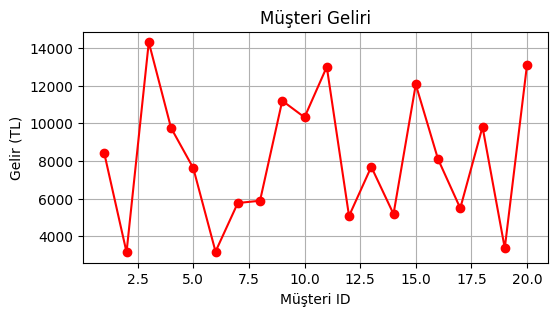

In [136]:
import matplotlib.pyplot as plt

# line plot
plt.figure(figsize = (6,3)) # 800 x 400'lük boş fig
plt.plot(veri["musteri_id"],veri["gelir"], marker = "o",
         color = "red") # x = müsteriid, y = gelir

plt.title("Müşteri Geliri")
plt.xlabel("Müşteri ID")
plt.ylabel("Gelir (TL)")
plt.grid() # ızgara
plt.show()

### Scatter plot (saçılım grafiği)
* korelasyon için

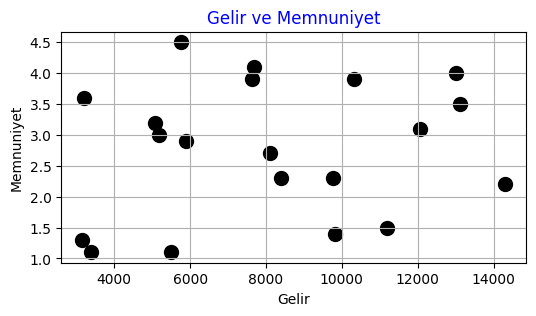

In [137]:
plt.figure(figsize = (6,3))
plt.scatter(veri["gelir"], veri['memnuniyet'], s=100,color = "black") # s -> size
plt.title("Gelir ve Memnuniyet",color ="blue")
plt.xlabel("Gelir")
plt.ylabel("Memnuniyet")
plt.grid()
plt.show()

### Bar plot (sütun grafiği)
* kategorik değişkenleri karşılaştırma


In [138]:
sehir_sayilari = veri["sehir"].value_counts()
sehir_sayilari

,count
sehir,
Bursa,6
Elazig,6
İstanbul,4
Ankara,4


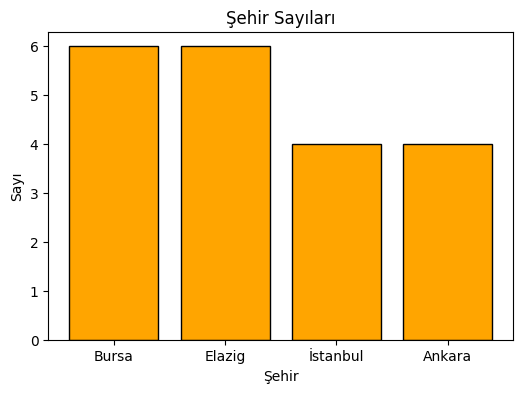

In [139]:
plt.figure(figsize=(6,4))
plt.bar(sehir_sayilari.index, sehir_sayilari.values, color = "orange", edgecolor = "black")
plt.title("Şehir Sayıları")
plt.xlabel("Şehir")
plt.ylabel("Sayı")
plt.show()

### pie chart (pasta grafiği)
* yüzdelik oranları görselleştirme

In [140]:
cinsiyet_dagilimi= veri["cinsiyet"].value_counts()
cinsiyet_dagilimi

,count
cinsiyet,
erkek,13
kadın,7


In [141]:
cinsiyet_dagilimi.index

Index(['erkek', 'kadın'], dtype='object', name='cinsiyet')

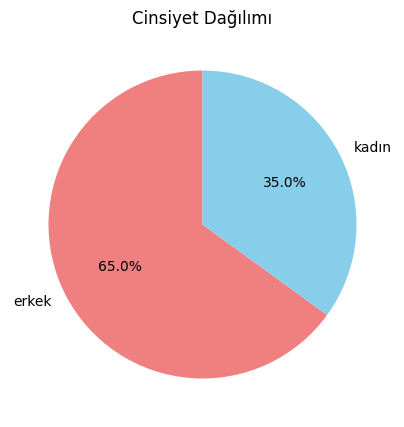

In [142]:
plt.figure(figsize = (5,5))
plt.pie(cinsiyet_dagilimi, labels = cinsiyet_dagilimi.index,
        autopct= "%1.1f%%", startangle = 90,
        colors = ["lightcoral", "skyblue"] )

plt.title("Cinsiyet Dağılımı")
plt.show()

### Histogram (veri dağılımı)
* sayısal değikenlerin dağılımı

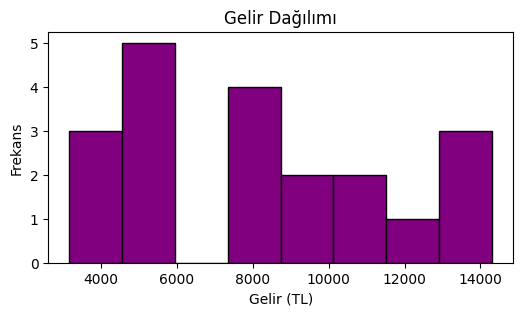

In [143]:
plt.figure(figsize = (6,3))
plt.hist(veri['gelir'], bins = 8, color = "purple",
         edgecolor = "black")
plt.title("Gelir Dağılımı")
plt.xlabel("Gelir (TL)")
plt.ylabel("Frekans")
plt.show()

### box plot (kutu grafiği)
* outlier tespiti

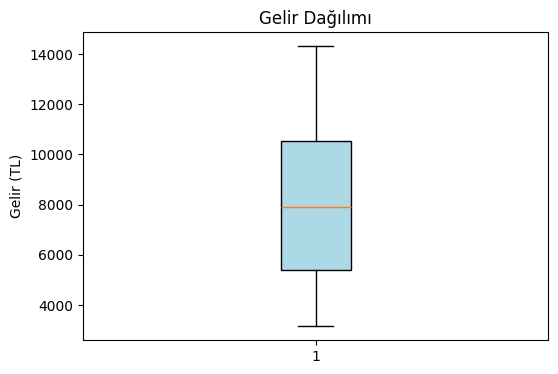

In [144]:
plt.figure(figsize = (6,4))
plt.boxplot(veri['gelir'],
            patch_artist=True, # içi dolu
            boxprops=dict(facecolor="lightblue")) # içinin rengi
# ortadaki çizgi medyan
# çizgiler g değerleri
plt.title("Gelir Dağılımı")
plt.ylabel("Gelir (TL)")

plt.show()

### subplot (çoklu grafik)
* birden fazla değişkeni aynı anda yorumlama

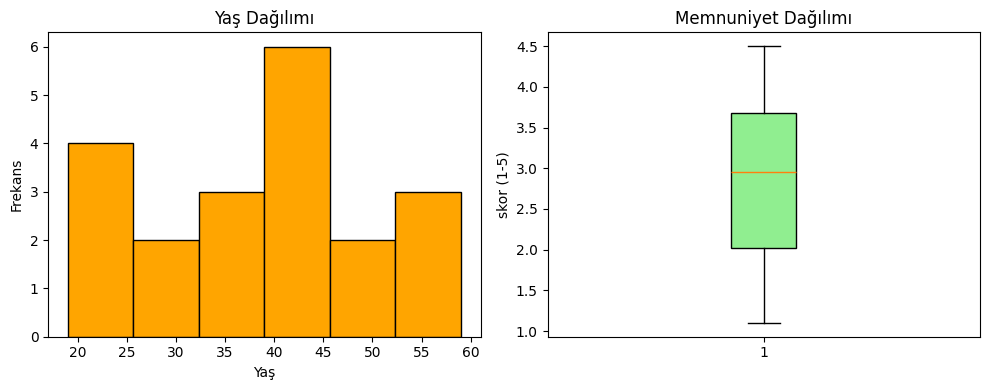

In [145]:
fig, axs = plt.subplots(1,2, figsize = (10,4))

axs[0].hist(veri['yas'], bins = 6, color = "orange", edgecolor = "black")
axs[0].set_title("Yaş Dağılımı")
axs[0].set_xlabel("Yaş")
axs[0].set_ylabel("Frekans")

axs[1].boxplot(veri["memnuniyet"], patch_artist=True,
               boxprops=dict(facecolor="lightgreen"))
axs[1].set_title("Memnuniyet Dağılımı")
axs[1].set_ylabel("skor (1-5)")

plt.tight_layout()

# Seaborn
* istatistiksel ve estetik açıdan güçlü grafikler


* Sayısal veriler için: histplot, kdeplot, boxplot, swarmplot
* Kategorik veriler için: countplot, barplot, stripplot, violingplot
* ilişki gösteren grafikler: scatterplot, lineplot, regplot, pairplot
* Korelasyon analizi: heatmap, clustermap, jointplot
* çoklu görselleştirme: facetgrid, catplot, relplot

## Sayısal veriler için dağılım grafikleri

In [146]:
# histogram

import pandas as pd
import numpy as np
import seaborn as sns

### Histplot

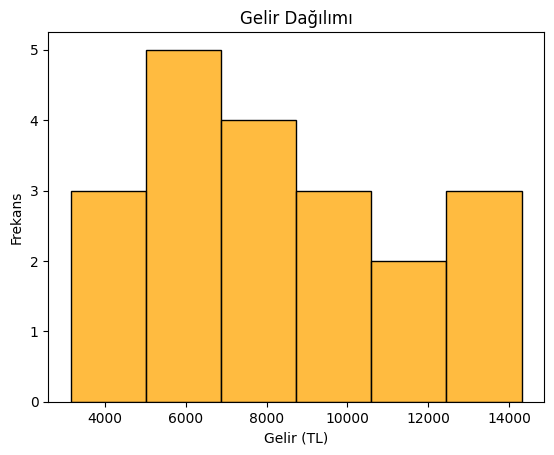

In [147]:
sns.histplot(data=veri,x ="gelir", bins = 6, kde = False, color = "orange", edgecolor = "black")
plt.title("Gelir Dağılımı")
plt.xlabel("Gelir (TL)")
plt.ylabel("Frekans")
plt.show()

### kernel density estimation: yoğunluk eğrisi


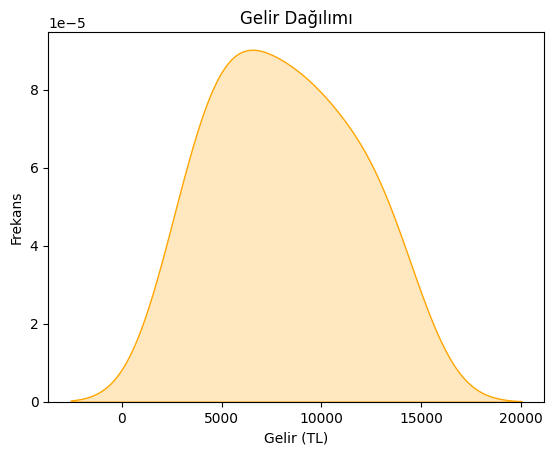

In [148]:
sns.kdeplot(data=veri, x = "gelir", fill=True,color = "orange")
plt.title("Gelir Dağılımı")
plt.xlabel("Gelir (TL)")
plt.ylabel("Frekans")
plt.show()


### histogram + kde


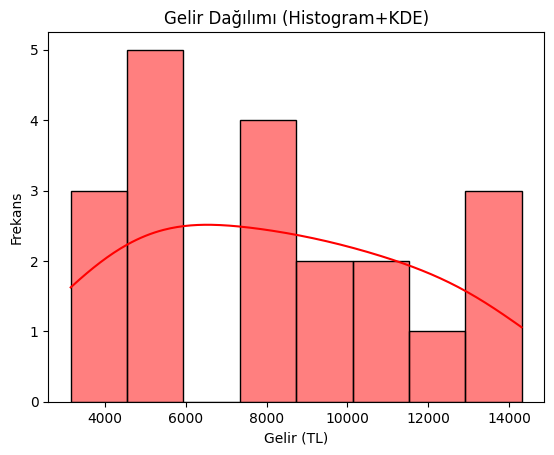

In [149]:
sns.histplot(data=veri, x = "gelir", bins=8, kde = True, color = "red", edgecolor = "black")
plt.title("Gelir Dağılımı (Histogram+KDE)")
plt.xlabel("Gelir (TL)")
plt.ylabel("Frekans")
plt.show()

#### box plot


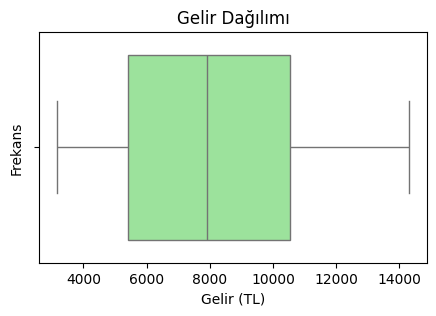

In [150]:
plt.figure(figsize=(5,3))
sns.boxplot(data=veri, x = "gelir", color="lightgreen")
plt.title("Gelir Dağılımı")
plt.xlabel("Gelir (TL)")
plt.ylabel("Frekans")
plt.show()

### violingplot (dağılım ve yoğunluğu)


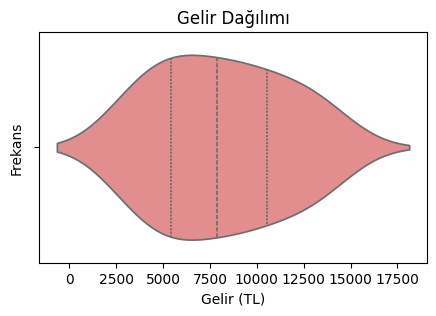

In [151]:
plt.figure(figsize=(5,3))
sns.violinplot(data=veri, x = "gelir",inner="quartile", color="lightcoral")
plt.title("Gelir Dağılımı")
plt.xlabel("Gelir (TL)")
plt.ylabel("Frekans")
plt.show()

## Kategorik değişkenler

### countplot - kategorilerin frekansı


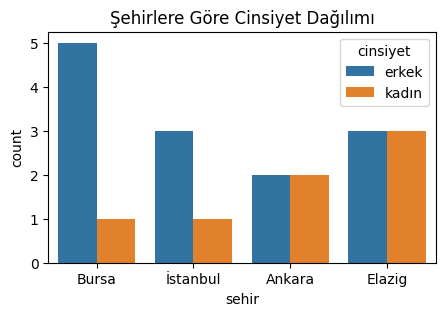

In [152]:

plt.figure(figsize=(5,3))
sns.countplot(data=veri, x = "sehir", hue = "cinsiyet")
plt.title("Şehirlere Göre Cinsiyet Dağılımı")
plt.show()

### barplot - kategorilere göre ort veya top değer


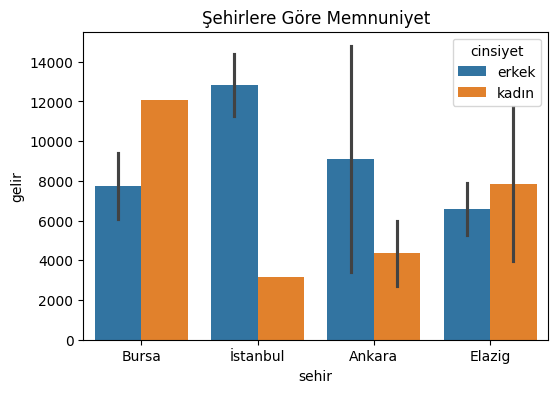

In [153]:
plt.figure(figsize=(6,4))
sns.barplot(data=veri, x = "sehir", y = "gelir", hue = "cinsiyet", errorbar = "sd" )
plt.title("Şehirlere Göre Memnuniyet")
plt.show()

### strip plot - tek tek noktaları gösterir


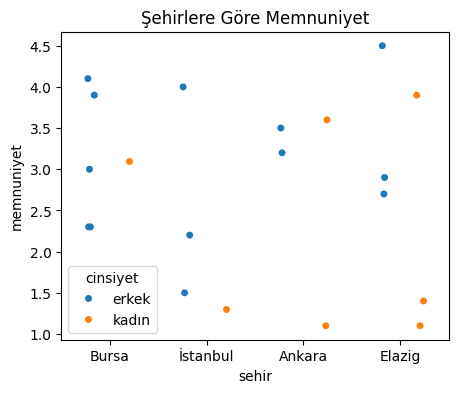

In [154]:
plt.figure(figsize=(5,4))
sns.stripplot(data=veri, x = "sehir", y = "memnuniyet", hue = "cinsiyet", jitter = True, dodge=True)
plt.title("Şehirlere Göre Memnuniyet")
plt.show()

### swarmp plot - noktalar çakıimadan yerleştirme (yoğunluk)


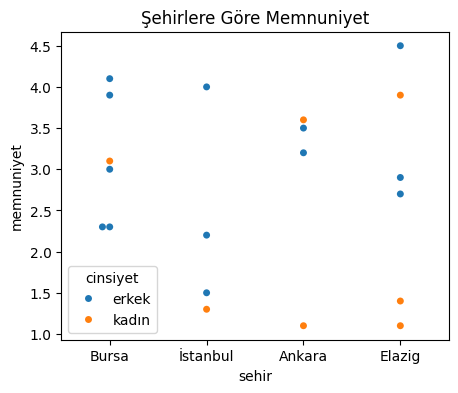

In [155]:

plt.figure(figsize=(5,4))
sns.swarmplot(data=veri, x = "sehir", y = "memnuniyet", hue = "cinsiyet")
plt.title("Şehirlere Göre Memnuniyet")
plt.show()


## ilişki gösteren grafikler

### scatrer plot - iki sayısal değişken arasındaki ilişki


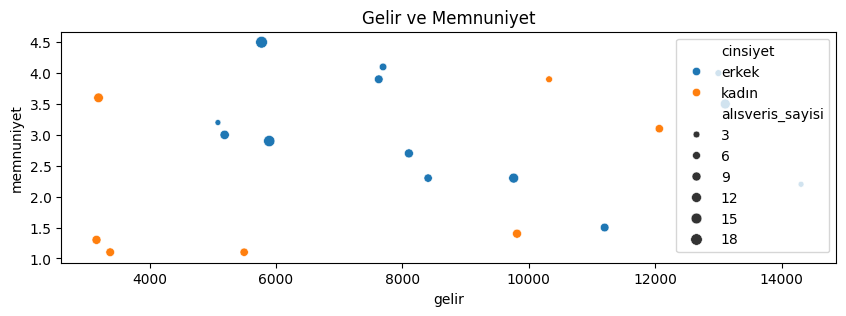

In [156]:
plt.figure(figsize=(10,3))
sns.scatterplot(data=veri, x = "gelir", y = "memnuniyet", hue = "cinsiyet",
                size = 'alısveris_sayisi')
plt.title("Gelir ve Memnuniyet")
plt.show()

### Line plot - değerlerin değişim eğilimi


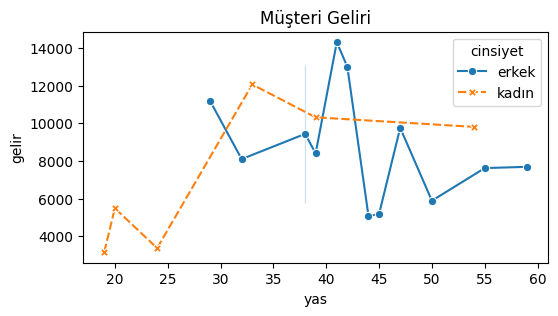

In [157]:
plt.figure(figsize=(6,3))
sns.lineplot(data=veri, x = "yas", y = "gelir", hue = "cinsiyet", style = "cinsiyet",
             markers = True)
plt.title("Müşteri Geliri")
plt.show()

### regplot - regresyon çizgili dağılım grafiği


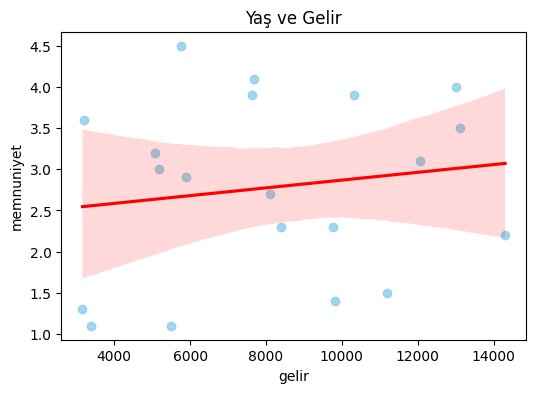

In [158]:
plt.figure(figsize=(6,4) )
sns.regplot(data=veri, x = "gelir", y = "memnuniyet", scatter_kws = {"color": "skyblue"},
            line_kws={"color":"red"})
plt.title("Yaş ve Gelir")
plt.show()

### pairplot - çoklu sayısal değişken ilişkisi

In [ ]:


sns.pairplot(veri[["yas", "gelir", "alısveris_sayisi", "memnuniyet"]], diag_kind="kde")
plt.suptitle("Sayısal değişkenler arası ilişkiler (pariplot)", y = 1.03)
plt.show()

## Korelasyon Analizleri

### heatmap

In [ ]:


plt.figure(figsize = (8,5))

sns.heatmap(veri.corr(numeric_only=True), annot=True, fmt=".2f" ,cmap="coolwarm")


plt.show()

### cluster map - kolerasyonları kümeleyerek gösterir


In [ ]:

sns.clustermap(veri.corr(numeric_only=True), annot=True, fmt=".2f" ,cmap="vlag")
plt.show()

### jointplot - iki değişkenin dağılımını regresyon çizgisi ile gösterir

In [ ]:


sns.jointplot(data=veri, x ="gelir", y = "memnuniyet", kind = "reg",
              color = "mediumseagreen")
plt.show()

## çoklu görselleştirme

### facetgrid - belli bir kateg göre bölünmüş alt grafikler

In [ ]:


g = sns.FacetGrid(veri, col ="cinsiyet")
g.map(sns.histplot, "gelir", bins = 6, color = "coral")

g.fig.suptitle("Cinsiyete Göre Gelir Dağılımı", y = 1.032)
plt.show()

### catplot - kategorik grafiklerin birleşimi

In [ ]:


sns.catplot(data=veri, x = "sehir", y = "gelir", hue = "cinsiyet", kind = "box",
            height = 5, aspect = 1.2)

plt.title("şehirlere göre gelir dağılımı")
plt.show()

### relplot - çoklu ilişki grafikleri

In [ ]:


sns.relplot(data=veri, x = "yas", y = "gelir", hue = "cinsiyet", size = "memnuniyet",
            kind = "scatter")
plt.title("Yaş - Gelir - Memnuniyet")
plt.show()